In [1]:
# Supply chain analysis of feedstock cost impact on MJSP
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters, additional_rcf
from lignin_saf.settings.prices import prices
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank


chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']




ethanol_in_beer = bst.Stream('Ethanol_In_Beer',
                       Ethanol=21507,
                       Water=391023,
                       Xylose=315.697,
                       Extract=12208.3,
                       AceticAcid=3663.85,
                       LacticAcid=2135.35,
                       Cellulose= 3504.6,
                       Xylan=1952.77,
                       Lignin=13131.8,
                       Protein=2635.1,
                       Ash=4107.85,
                       Cellulase=1681.7,
                       units = 'kg/hr',
                       T=115+273.15,
                       P = 6*101325)


beer_shortcut = bst.units.ShortcutColumn(
    ins = ethanol_in_beer,
    outs = ('shortcut_beer_top','shortcut_beer_bottom'),
    P = 3*101325,
    LHK=('Ethanol', 'Water'),
    Lr = 0.9913,
    Hr = 0.90717,
    k = 2,
    partial_condenser=True
)
beer_shortcut.simulate()


rectification_shortcut = bst.units.ShortcutColumn(
    ins = beer_shortcut-0,
    outs = ('shortcut_rectif_top','shortcut_rectif_bottom'),
    P = 3*101325,
    LHK=('Ethanol', 'Water'),
    y_top = 0.925/1.11,
    x_bot = 0.0005/2.55,
    k = 1.05
)
rectification_shortcut.simulate()


# =====================================================================
# Rigorous (MESH) beer and rectification columns, seeded from the
# converged shortcut columns above (same shortcut->rigorous handoff
# pattern as the BioSTEAM acetic acid tutorial). Neither column has an
# internal condenser (reflux=0): overhead product leaves fully vaporized.
# Column 2's overhead is instead condensed externally against a process
# water stream, split by a simplified molecular-sieve model, and the
# reject (topped up with makeup water) is recycled back in as a second
# feed at stage 1 -- acting like reflux, but as an external feed rather
# than the column's internal reflux mechanism.
#
# NOTE: N_stages/boilup are pulled directly from the shortcut columns'
# converged design, but the shortcut rectification column relies on a
# large internal reflux (R=15.3) to hit its y_top=0.833 spec. With
# reflux=0 here, column 2 does NOT reach that purity (~11 mol% ethanol
# overhead instead of ~83 mol%) -- the water balance in the recycle loop
# is dominated by this shortfall. Purity has not yet been matched;
# structure/wiring is the priority for now.
# =====================================================================

def _boilup_ratio(shortcut_column):
    outlet = shortcut_column.reboiler.outs[0]
    return outlet['g'].F_mol / outlet['l'].F_mol

boilup_beer = _boilup_ratio(beer_shortcut)
boilup_rectif = _boilup_ratio(rectification_shortcut)

N_stages_beer = int(beer_shortcut.design_results['Theoretical stages'])
feed_stage_beer = int(beer_shortcut.design_results['Theoretical feed stage'])
N_stages_rectif = max(int(rectification_shortcut.design_results['Theoretical stages']), 11)
feed_stage_rectif = int(rectification_shortcut.design_results['Theoretical feed stage'])



beer_shortcut_2 = bst.units.ShortcutColumn(
    ins = ethanol_in_beer,
    outs = ('shortcut_beer_2_top','shortcut_beer_2_bottom'),
    P = 3*101325,
    LHK=('Ethanol', 'Water'),
    Lr = 0.9913,
    Hr = 0.90717,
    k = 2,
    partial_condenser=True
)


"""
# --- Column 1: beer/stripping MESH column. No condenser (reflux=0):
# the top vapor leaves the column fully vaporized and feeds column 2 directly.
beer_mesh = bst.MESHDistillation(
    'beer_mesh',
    ins=(ethanol_in_beer,),
    outs=('beer_mesh_vapor', 'beer_mesh_bottoms'),
    N_stages=N_stages_beer,
    feed_stages=[feed_stage_beer],
    reflux=beer_shortcut.design_results['Minimum reflux'],
    boilup=boilup_beer,
    LHK=('Ethanol', 'Water'),
    P=3*101325,
)
"""



# --- Column 2: rectification MESH column. Also no internal condenser;
# "reflux" instead re-enters as a second feed at stage 1 (top stage), coming
# from the molecular-sieve loop below -- same pattern as the acetic acid
# tutorial's externally-supplied reflux feed. Initial guess matches the
# target reject composition to help the recycle solver converge.
reflux_recycle = bst.Stream('reflux_recycle', Ethanol=5331.9, Water=2043,
                             units='kg/hr', T=71+273.15, P=3*101325, phase='l')

rectif_mesh = bst.MESHDistillation(
    'rectif_mesh',
    ins=(beer_shortcut_2-0, reflux_recycle),
    outs=('rectif_mesh_vapor', 'rectif_mesh_bottoms'),
    N_stages=N_stages_rectif,   # 15
    feed_stages=[3,1],
    reflux=rectification_shortcut.design_results['Minimum reflux'],
    boilup=boilup_rectif,
    LHK=('Ethanol', 'Water'),
    P=3*101325
)

# --- Heat recovery: condense the rectifier's vapor product against process
# water (33 C -> 100 C), sized by direct energy balance each pass.
sieve_water_in = bst.Stream('sieve_water_in', Water=1, units='kmol/hr',
                             T=33+273.15, P=101325, phase='l')

HX_sieve = bst.HXprocess(
    'HX_sieve',
    ins=(rectif_mesh-0, sieve_water_in),
    outs=('rectif_vapor_cooled', 'sieve_water_heated'),
)

@HX_sieve.add_specification(run=True)
def set_sieve_water_flow():
    vapor_in = HX_sieve.ins[0]
    liquid_ref = vapor_in.copy()
    liquid_ref.phase = 'l'
    Q = vapor_in.H - liquid_ref.H  # duty released condensing vapor to liquid at column P
    water_ref_in = bst.Stream(None, Water=1, units='kmol/hr', T=33+273.15,
                               P=101325, phase='l', thermo=chems)
    water_ref_out = water_ref_in.copy()
    water_ref_out.T = 100+273.15
    dH_per_kmol = water_ref_out.H - water_ref_in.H
    HX_sieve.ins[1].imol['Water'] = Q / dH_per_kmol

# --- Molecular sieve, modeled as a component splitter: rejects exactly
# enough water and ethanol (capped at what's actually available) to target
# a reject of 5331.9 kg/hr ethanol / 2043 kg/hr water, recomputed every
# pass from the *actual* HX_sieve outlet -- not the static shortcut-column
# snapshot, which drifts arbitrarily far from the converged MESH column's
# real overhead flow once N_stages/reflux/feed_stages change. AceticAcid/
# LacticAcid are not water-selective, so they're routed entirely to
# product -- leaving them unspecified defaults them to the reject side and
# causes runaway accumulation in the recycle loop.
target_reflux_ethanol = 5331.9  # kg/hr
target_reflux_water = 2043      # kg/hr

molecular_sieve = bst.Splitter(
    'molecular_sieve',
    ins=HX_sieve-0,
    outs=('sieve_product', 'sieve_reject'),
    split=dict(Ethanol=0.0, Water=0.0, AceticAcid=1.0, LacticAcid=1.0),
)

@molecular_sieve.add_specification(run=True)
def set_molecular_sieve_split():
    feed = molecular_sieve.ins[0]
    avail_ethanol = feed.imass['Ethanol']
    avail_water = feed.imass['Water']
    ethanol_reject_frac = min(target_reflux_ethanol / avail_ethanol, 1.0) if avail_ethanol > 0 else 0.0
    water_reject_frac = min(target_reflux_water / avail_water, 1.0) if avail_water > 0 else 0.0
    molecular_sieve.isplit['Ethanol'] = 1 - ethanol_reject_frac
    molecular_sieve.isplit['Water'] = 1 - water_reject_frac

# --- Makeup water tops the sieve reject up to the target reflux water flow
# (only needed if the column's overhead can't supply 2043 kg/hr water on
# its own; recomputed every pass). No pump: makeup water is assumed
# available at 3 atm already.
makeup_water = bst.Stream('makeup_water', Water=0, units='kg/hr',
                           T=25+273.15, P=3*101325, phase='l')

reflux_mixer = bst.Mixer('reflux_mixer', ins=(molecular_sieve-1, makeup_water),
                          outs='reflux_mixed')

@reflux_mixer.add_specification(run=True)
def set_makeup_water_flow():
    reject_water = molecular_sieve.outs[1].imass['Water']
    makeup_water.imass['Water'] = max(target_reflux_water - reject_water, 0.0)

# Final cooler brings the combined reject + makeup water back to 71 C before
# re-entering the column; no pump/compressor -- pressure carries through at 3 atm.
cooler_reflux = bst.HXutility('cooler_reflux', ins=reflux_mixer-0,
                               outs=reflux_recycle, T=71+273.15,
                               rigorous=True)

rectif_loop_sys = bst.System(
    'rectif_loop_sys',
    path=(beer_shortcut_2, rectif_mesh, HX_sieve, molecular_sieve, reflux_mixer, cooler_reflux),
    recycle=reflux_recycle,
)
rectif_loop_sys.simulate()


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\pressure_vessel.py:104: CostWarning: <RefluxDrum: reflux_drum> Vertical vessel length (9 ft) is out of bounds (12 to 40 ft) for cost correlation
  return method(pressure, diameter, length)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\IPython\core\interactiveshell.py:3579: RuntimeWarning: undocked inlet Ethanol_In_Beer from D1; Ethanol_In_Beer is now docked at D3
  exec(code_obj, self.user_global_ns, self.user_ns)


In [2]:
rectification_shortcut.show(flow='kg/hr',composition=True)

ShortcutColumn: D2
ins...
[0] shortcut_beer_top  from  ShortcutColumn-D1
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
outs...
[0] shortcut_rectif_top  
    phase: 'g', T: 382.22 K, P: 303975 Pa
    composition (%): Water       7.25
                     Ethanol     92.7
                     AceticAcid  0.00184
                     ----------  2.3e+04 kg/hr
[1] shortcut_rectif_bottom  
    phase: 'l', T: 406.96 K, P: 303975 Pa
    composition (%): Water       97.9
                     Ethanol     0.0491
                     AceticAcid  2.06
                     LacticAcid  0.000122
                     ----------  3.54e+04 kg/hr


In [3]:
beer_shortcut.show(flow='kg/hr')

ShortcutColumn: D1
ins...
[0] missing stream  
outs...
[0] shortcut_beer_top  to  ShortcutColumn-D2
    phase: 'g', T: 400.82 K, P: 303975 Pa
    flow (kg/hr): Water       3.63e+04
                  Ethanol     2.13e+04
                  AceticAcid  728
                  LacticAcid  0.0432
[1] shortcut_beer_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    flow (kg/hr): Water       3.55e+05
                  Ethanol     187
                  AceticAcid  2.94e+03
                  LacticAcid  2.14e+03
                  Xylose      316
                  Extract     1.22e+04
                  Ash         4.11e+03
                  ...         2.29e+04


In [4]:
beer_shortcut_2.show(flow='kg/hr')

ShortcutColumn: D3
ins...
[0] Ethanol_In_Beer  
    phase: 'l', T: 388.15 K, P: 607950 Pa
    flow (kg/hr): Water       3.91e+05
                  Ethanol     2.15e+04
                  AceticAcid  3.66e+03
                  LacticAcid  2.14e+03
                  Xylose      316
                  Extract     1.22e+04
                  Ash         4.11e+03
                  ...         2.29e+04
outs...
[0] shortcut_beer_2_top  to  MESHDistillation-rectif_mesh
    phase: 'g', T: 400.82 K, P: 303975 Pa
    flow (kg/hr): Water       3.63e+04
                  Ethanol     2.13e+04
                  AceticAcid  728
                  LacticAcid  0.0432
[1] shortcut_beer_2_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    flow (kg/hr): Water       3.55e+05
                  Ethanol     187
                  AceticAcid  2.94e+03
                  LacticAcid  2.14e+03
                  Xylose      316
                  Extract     1.22e+04
                  Ash         4.11e+03
            

In [5]:
rectif_mesh.show(flow='kg/hr',composition=True)

MESHDistillation: rectif_mesh
ins...
[0] shortcut_beer_2_top  from  ShortcutColumn-D3
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] reflux_recycle  from  HXutility-cooler_reflux
    phases: ('g', 'l'), T: 344.15 K, P: 303975 Pa
    composition (%): (l) Water    27.7
                         Ethanol  72.3
                         -------  7.37e+03 kg/hr
outs...
[0] rectif_mesh_vapor  to  HXprocess-HX_sieve
    phase: 'g', T: 384.25 K, P: 303975 Pa
    composition (%): Water       19
                     Ethanol     80.9
                     AceticAcid  0.091
                     LacticAcid  3.72e-13
                     ----------  3.26e+04 kg/hr
[1] rectif_mesh_bottoms  
    phase: 'l', T: 406.01 K, P: 303975 Pa
    composition (%): Water       97.2
                     Ethanol     0.70

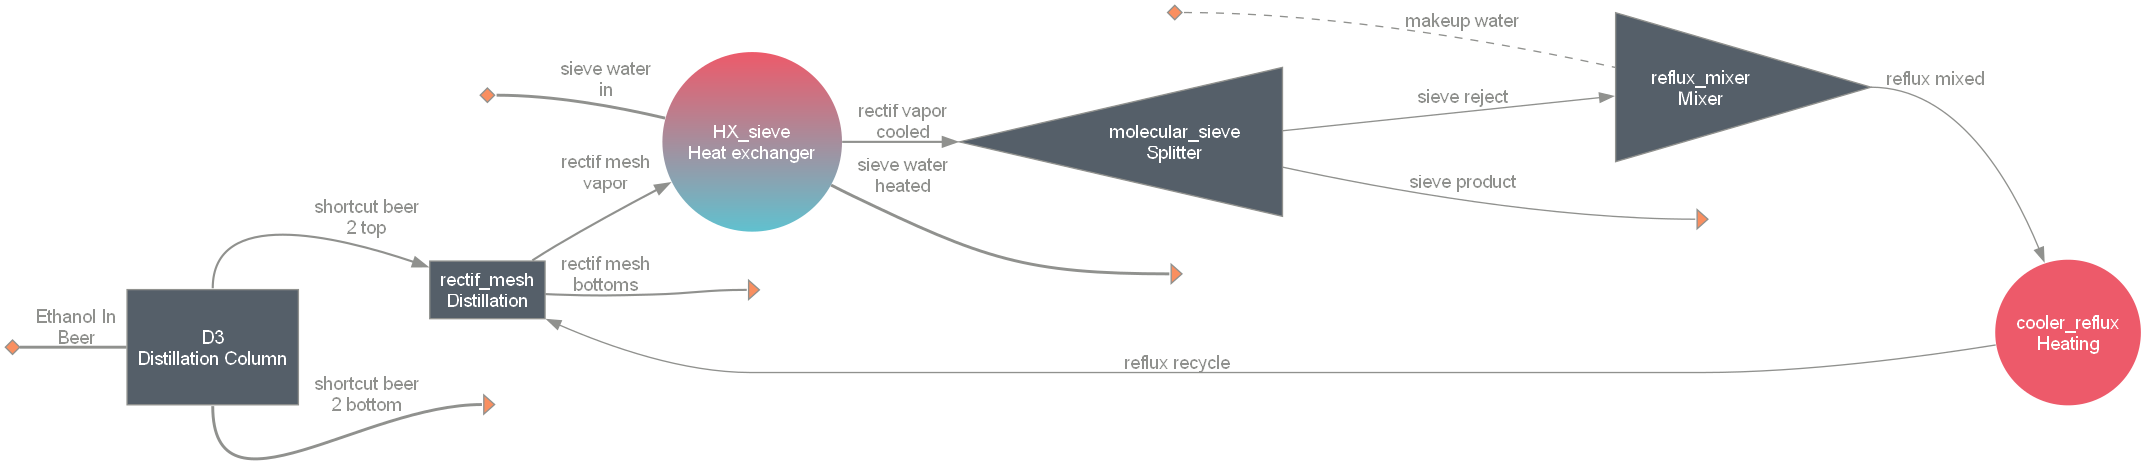

In [6]:
rectif_loop_sys.diagram(format='png')

In [7]:
rectification_shortcut.results()

Distillation Column                                        Units        D2
Electricity         Power                                     kW      3.05
                    Cost                                  USD/hr     0.252
Cooling water       Duty                                   kJ/hr -1.12e+08
                    Flow                                 kmol/hr  7.66e+04
                    Cost                                  USD/hr      37.4
Low pressure steam  Duty                                   kJ/hr  4.29e+07
                    Flow                                 kmol/hr  1.11e+03
                    Cost                                  USD/hr       264
Design              Theoretical feed stage                               2
                    Theoretical stages                                  23
                    Minimum reflux                         Ratio      5.11
                    Reflux                                 Ratio      5.36
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft        13
                    Wall thickness                            in     0.625
                    Weight                                    lb  7.68e+04
Purchase cost       Trays                                    USD  1.62e+05
                    Tower                                    USD  3.46e+05
                    Platform and ladders                     USD  7.08e+04
                    Condenser - Floating head                USD  1.68e+05
                    Reflux drum - Horizontal pressur...      USD  3.19e+04
                    Reflux drum - Platform and ladders       USD  4.93e+03
                    Pump - Pump                              USD  6.95e+03
                    Pump - Motor                             USD       678
                    Reboiler - Floating head                 USD  3.56e+05
Total purchase cost                                          USD  1.15e+06
Utility cost                                              USD/hr       301

In [8]:
rectif_mesh.show(composition=True, flow='kg/hr')

MESHDistillation: rectif_mesh
ins...
[0] shortcut_beer_2_top  from  ShortcutColumn-D3
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] reflux_recycle  from  HXutility-cooler_reflux
    phases: ('g', 'l'), T: 344.15 K, P: 303975 Pa
    composition (%): (l) Water    27.7
                         Ethanol  72.3
                         -------  7.37e+03 kg/hr
outs...
[0] rectif_mesh_vapor  to  HXprocess-HX_sieve
    phase: 'g', T: 384.25 K, P: 303975 Pa
    composition (%): Water       19
                     Ethanol     80.9
                     AceticAcid  0.091
                     LacticAcid  3.72e-13
                     ----------  3.26e+04 kg/hr
[1] rectif_mesh_bottoms  
    phase: 'l', T: 406.01 K, P: 303975 Pa
    composition (%): Water       97.2
                     Ethanol     0.70

In [9]:
rectification_shortcut.show(flow='kg/hr', composition=True)

ShortcutColumn: D2
ins...
[0] shortcut_beer_top  from  ShortcutColumn-D1
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
outs...
[0] shortcut_rectif_top  
    phase: 'g', T: 382.22 K, P: 303975 Pa
    composition (%): Water       7.25
                     Ethanol     92.7
                     AceticAcid  0.00184
                     ----------  2.3e+04 kg/hr
[1] shortcut_rectif_bottom  
    phase: 'l', T: 406.96 K, P: 303975 Pa
    composition (%): Water       97.9
                     Ethanol     0.0491
                     AceticAcid  2.06
                     LacticAcid  0.000122
                     ----------  3.54e+04 kg/hr


In [10]:
beer_shortcut.show(flow='kg/hr',composition=True)

ShortcutColumn: D1
ins...
[0] missing stream  
outs...
[0] shortcut_beer_top  to  ShortcutColumn-D2
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] shortcut_beer_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    composition (%): Water       88.8
                     Ethanol     0.0468
                     AceticAcid  0.735
                     LacticAcid  0.534
                     Xylose      0.079
                     Extract     3.06
                     Ash         1.03
                     ...         5.73
                     ----------  4e+05 kg/hr


In [11]:
rectification_shortcut.results()

Distillation Column                                        Units        D2
Electricity         Power                                     kW      3.05
                    Cost                                  USD/hr     0.252
Cooling water       Duty                                   kJ/hr -1.12e+08
                    Flow                                 kmol/hr  7.66e+04
                    Cost                                  USD/hr      37.4
Low pressure steam  Duty                                   kJ/hr  4.29e+07
                    Flow                                 kmol/hr  1.11e+03
                    Cost                                  USD/hr       264
Design              Theoretical feed stage                               2
                    Theoretical stages                                  23
                    Minimum reflux                         Ratio      5.11
                    Reflux                                 Ratio      5.36
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft        13
                    Wall thickness                            in     0.625
                    Weight                                    lb  7.68e+04
Purchase cost       Trays                                    USD  1.62e+05
                    Tower                                    USD  3.46e+05
                    Platform and ladders                     USD  7.08e+04
                    Condenser - Floating head                USD  1.68e+05
                    Reflux drum - Horizontal pressur...      USD  3.19e+04
                    Reflux drum - Platform and ladders       USD  4.93e+03
                    Pump - Pump                              USD  6.95e+03
                    Pump - Motor                             USD       678
                    Reboiler - Floating head                 USD  3.56e+05
Total purchase cost                                          USD  1.15e+06
Utility cost                                              USD/hr       301

In [12]:
beer_shortcut.results()

Distillation Column                                        Units        D1
Electricity         Power                                     kW      17.9
                    Cost                                  USD/hr      1.48
Cooling water       Duty                                   kJ/hr -1.97e+06
                    Flow                                 kmol/hr  1.35e+03
                    Cost                                  USD/hr     0.657
Low pressure steam  Duty                                   kJ/hr  1.38e+08
                    Flow                                 kmol/hr  3.57e+03
                    Cost                                  USD/hr       849
Design              Theoretical feed stage                               1
                    Theoretical stages                                  13
                    Minimum reflux                         Ratio      0.01
                    Reflux                                 Ratio      0.02
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft      9.69
                    Wall thickness                            in     0.438
                    Weight                                    lb  3.85e+04
Purchase cost       Trays                                    USD  9.91e+04
                    Tower                                    USD  2.16e+05
                    Platform and ladders                     USD  5.87e+04
                    Condenser - Double pipe                  USD  8.07e+03
                    Reflux drum - Vertical pressure ...      USD  9.23e+04
                    Reflux drum - Platform and ladders       USD  1.75e+04
                    Pump - Pump                              USD  1.99e+04
                    Pump - Motor                             USD  1.62e+03
                    Reboiler - Floating head                 USD  5.13e+05
Total purchase cost                                          USD  1.03e+06
Utility cost                                              USD/hr       851

In [13]:
rectification_shortcut.results()

Distillation Column                                        Units        D2
Electricity         Power                                     kW      3.05
                    Cost                                  USD/hr     0.252
Cooling water       Duty                                   kJ/hr -1.12e+08
                    Flow                                 kmol/hr  7.66e+04
                    Cost                                  USD/hr      37.4
Low pressure steam  Duty                                   kJ/hr  4.29e+07
                    Flow                                 kmol/hr  1.11e+03
                    Cost                                  USD/hr       264
Design              Theoretical feed stage                               2
                    Theoretical stages                                  23
                    Minimum reflux                         Ratio      5.11
                    Reflux                                 Ratio      5.36
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft        13
                    Wall thickness                            in     0.625
                    Weight                                    lb  7.68e+04
Purchase cost       Trays                                    USD  1.62e+05
                    Tower                                    USD  3.46e+05
                    Platform and ladders                     USD  7.08e+04
                    Condenser - Floating head                USD  1.68e+05
                    Reflux drum - Horizontal pressur...      USD  3.19e+04
                    Reflux drum - Platform and ladders       USD  4.93e+03
                    Pump - Pump                              USD  6.95e+03
                    Pump - Motor                             USD       678
                    Reboiler - Floating head                 USD  3.56e+05
Total purchase cost                                          USD  1.15e+06
Utility cost                                              USD/hr       301

In [14]:
rectif_mesh.results()

Distillation                                               Units  rectif_mesh
Electricity         Power                                     kW         2.75
                    Cost                                  USD/hr        0.227
Cooling water       Duty                                   kJ/hr    -1.85e+08
                    Flow                                 kmol/hr     1.26e+05
                    Cost                                  USD/hr         61.6
Low pressure steam  Duty                                   kJ/hr     3.24e+07
                    Flow                                 kmol/hr          837
                    Cost                                  USD/hr          199
Design              Theoretical stages                                     23
                    Actual stages                                          35
                    Height                                    ft         65.7
                    Diameter                                  ft         13.6
                    Wall thickness                            in        0.625
                    Weight                                    lb     8.39e+04
Purchase cost       Trays                                    USD     1.77e+05
                    Tower                                    USD     3.68e+05
                    Platform and ladders                     USD     7.55e+04
                    Condenser - Floating head                USD     2.44e+05
                    Reflux drum - Horizontal pressur...      USD     2.84e+04
                    Reflux drum - Platform and ladders       USD     4.85e+03
                    Pump - Pump                              USD     6.83e+03
                    Pump - Motor                             USD          664
                    Reboiler - Floating head                 USD     2.13e+05
Total purchase cost                                          USD     1.12e+06
Utility cost                                              USD/hr          261

In [15]:
beer_shortcut.show(flow='kg/hr', composition=True)

ShortcutColumn: D1
ins...
[0] missing stream  
outs...
[0] shortcut_beer_top  to  ShortcutColumn-D2
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] shortcut_beer_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    composition (%): Water       88.8
                     Ethanol     0.0468
                     AceticAcid  0.735
                     LacticAcid  0.534
                     Xylose      0.079
                     Extract     3.06
                     Ash         1.03
                     ...         5.73
                     ----------  4e+05 kg/hr


In [16]:
rectification_shortcut.results()

Distillation Column                                        Units        D2
Electricity         Power                                     kW      3.05
                    Cost                                  USD/hr     0.252
Cooling water       Duty                                   kJ/hr -1.12e+08
                    Flow                                 kmol/hr  7.66e+04
                    Cost                                  USD/hr      37.4
Low pressure steam  Duty                                   kJ/hr  4.29e+07
                    Flow                                 kmol/hr  1.11e+03
                    Cost                                  USD/hr       264
Design              Theoretical feed stage                               2
                    Theoretical stages                                  23
                    Minimum reflux                         Ratio      5.11
                    Reflux                                 Ratio      5.36
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft        13
                    Wall thickness                            in     0.625
                    Weight                                    lb  7.68e+04
Purchase cost       Trays                                    USD  1.62e+05
                    Tower                                    USD  3.46e+05
                    Platform and ladders                     USD  7.08e+04
                    Condenser - Floating head                USD  1.68e+05
                    Reflux drum - Horizontal pressur...      USD  3.19e+04
                    Reflux drum - Platform and ladders       USD  4.93e+03
                    Pump - Pump                              USD  6.95e+03
                    Pump - Motor                             USD       678
                    Reboiler - Floating head                 USD  3.56e+05
Total purchase cost                                          USD  1.15e+06
Utility cost                                              USD/hr       301

In [17]:
rectif_mesh.results()

Distillation                                               Units  rectif_mesh
Electricity         Power                                     kW         2.75
                    Cost                                  USD/hr        0.227
Cooling water       Duty                                   kJ/hr    -1.85e+08
                    Flow                                 kmol/hr     1.26e+05
                    Cost                                  USD/hr         61.6
Low pressure steam  Duty                                   kJ/hr     3.24e+07
                    Flow                                 kmol/hr          837
                    Cost                                  USD/hr          199
Design              Theoretical stages                                     23
                    Actual stages                                          35
                    Height                                    ft         65.7
                    Diameter                                  ft         13.6
                    Wall thickness                            in        0.625
                    Weight                                    lb     8.39e+04
Purchase cost       Trays                                    USD     1.77e+05
                    Tower                                    USD     3.68e+05
                    Platform and ladders                     USD     7.55e+04
                    Condenser - Floating head                USD     2.44e+05
                    Reflux drum - Horizontal pressur...      USD     2.84e+04
                    Reflux drum - Platform and ladders       USD     4.85e+03
                    Pump - Pump                              USD     6.83e+03
                    Pump - Motor                             USD          664
                    Reboiler - Floating head                 USD     2.13e+05
Total purchase cost                                          USD     1.12e+06
Utility cost                                              USD/hr          261

In [18]:
beer_shortcut.results()

Distillation Column                                        Units        D1
Electricity         Power                                     kW      17.9
                    Cost                                  USD/hr      1.48
Cooling water       Duty                                   kJ/hr -1.97e+06
                    Flow                                 kmol/hr  1.35e+03
                    Cost                                  USD/hr     0.657
Low pressure steam  Duty                                   kJ/hr  1.38e+08
                    Flow                                 kmol/hr  3.57e+03
                    Cost                                  USD/hr       849
Design              Theoretical feed stage                               1
                    Theoretical stages                                  13
                    Minimum reflux                         Ratio      0.01
                    Reflux                                 Ratio      0.02
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft      9.69
                    Wall thickness                            in     0.438
                    Weight                                    lb  3.85e+04
Purchase cost       Trays                                    USD  9.91e+04
                    Tower                                    USD  2.16e+05
                    Platform and ladders                     USD  5.87e+04
                    Condenser - Double pipe                  USD  8.07e+03
                    Reflux drum - Vertical pressure ...      USD  9.23e+04
                    Reflux drum - Platform and ladders       USD  1.75e+04
                    Pump - Pump                              USD  1.99e+04
                    Pump - Motor                             USD  1.62e+03
                    Reboiler - Floating head                 USD  5.13e+05
Total purchase cost                                          USD  1.03e+06
Utility cost                                              USD/hr       851

In [19]:
rectification_outlet = rectification_shortcut.reboiler.outs[0]
rectification_outlet['g'].F_mol/(rectification_outlet['l'].F_mol)

0.5383745105437383

In [20]:
rectif_mesh.show(flow='kg/hr',composition=True)

MESHDistillation: rectif_mesh
ins...
[0] shortcut_beer_2_top  from  ShortcutColumn-D3
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] reflux_recycle  from  HXutility-cooler_reflux
    phases: ('g', 'l'), T: 344.15 K, P: 303975 Pa
    composition (%): (l) Water    27.7
                         Ethanol  72.3
                         -------  7.37e+03 kg/hr
outs...
[0] rectif_mesh_vapor  to  HXprocess-HX_sieve
    phase: 'g', T: 384.25 K, P: 303975 Pa
    composition (%): Water       19
                     Ethanol     80.9
                     AceticAcid  0.091
                     LacticAcid  3.72e-13
                     ----------  3.26e+04 kg/hr
[1] rectif_mesh_bottoms  
    phase: 'l', T: 406.01 K, P: 303975 Pa
    composition (%): Water       97.2
                     Ethanol     0.70

In [21]:
rectif_mesh.show(flow='kg/hr',composition=True)

MESHDistillation: rectif_mesh
ins...
[0] shortcut_beer_2_top  from  ShortcutColumn-D3
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] reflux_recycle  from  HXutility-cooler_reflux
    phases: ('g', 'l'), T: 344.15 K, P: 303975 Pa
    composition (%): (l) Water    27.7
                         Ethanol  72.3
                         -------  7.37e+03 kg/hr
outs...
[0] rectif_mesh_vapor  to  HXprocess-HX_sieve
    phase: 'g', T: 384.25 K, P: 303975 Pa
    composition (%): Water       19
                     Ethanol     80.9
                     AceticAcid  0.091
                     LacticAcid  3.72e-13
                     ----------  3.26e+04 kg/hr
[1] rectif_mesh_bottoms  
    phase: 'l', T: 406.01 K, P: 303975 Pa
    composition (%): Water       97.2
                     Ethanol     0.70

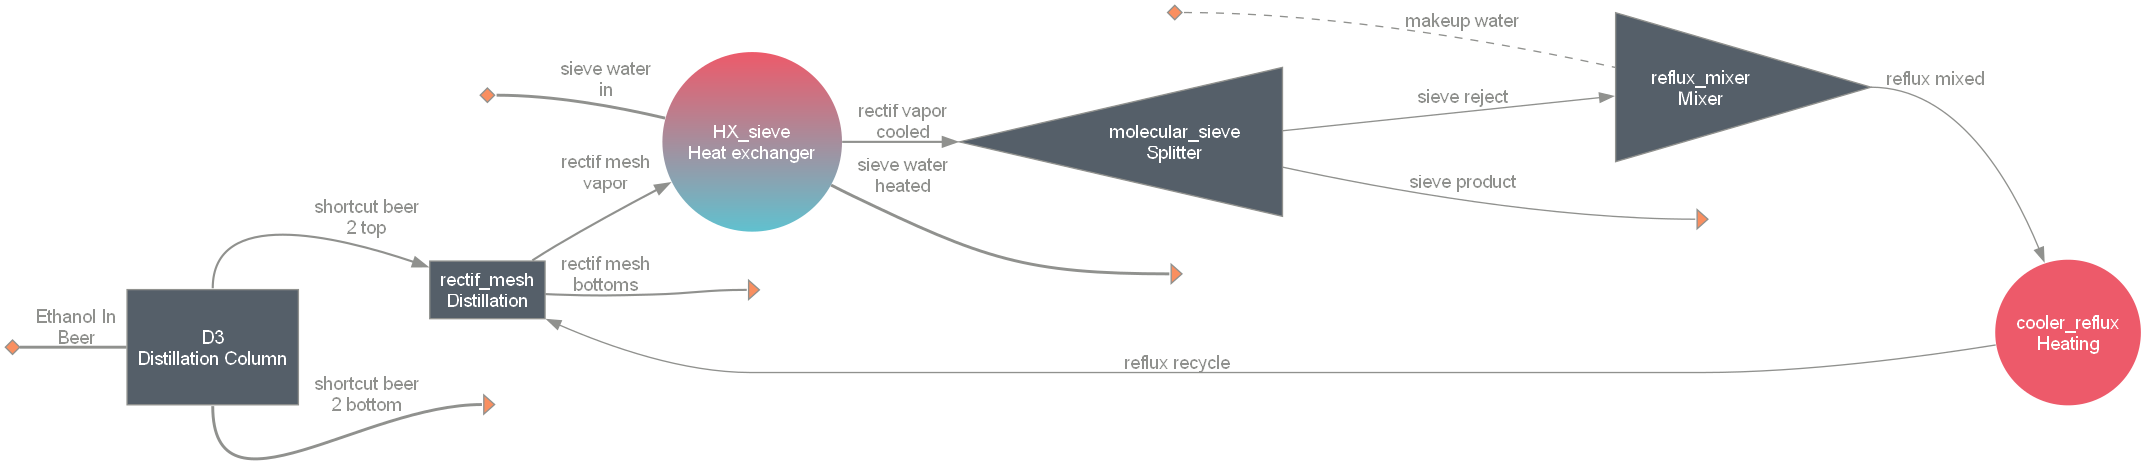

In [22]:
rectif_loop_sys.diagram(format='png')


In [23]:
rectif_mesh.results()

Distillation                                               Units  rectif_mesh
Electricity         Power                                     kW         2.75
                    Cost                                  USD/hr        0.227
Cooling water       Duty                                   kJ/hr    -1.85e+08
                    Flow                                 kmol/hr     1.26e+05
                    Cost                                  USD/hr         61.6
Low pressure steam  Duty                                   kJ/hr     3.24e+07
                    Flow                                 kmol/hr          837
                    Cost                                  USD/hr          199
Design              Theoretical stages                                     23
                    Actual stages                                          35
                    Height                                    ft         65.7
                    Diameter                                  ft         13.6
                    Wall thickness                            in        0.625
                    Weight                                    lb     8.39e+04
Purchase cost       Trays                                    USD     1.77e+05
                    Tower                                    USD     3.68e+05
                    Platform and ladders                     USD     7.55e+04
                    Condenser - Floating head                USD     2.44e+05
                    Reflux drum - Horizontal pressur...      USD     2.84e+04
                    Reflux drum - Platform and ladders       USD     4.85e+03
                    Pump - Pump                              USD     6.83e+03
                    Pump - Motor                             USD          664
                    Reboiler - Floating head                 USD     2.13e+05
Total purchase cost                                          USD     1.12e+06
Utility cost                                              USD/hr          261

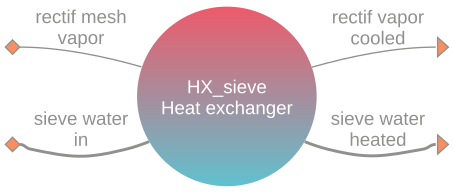

HXprocess: HX_sieve
ins...
[0] rectif_mesh_vapor  from  MESHDistillation-rectif_mesh
    phase: 'g', T: 384.25 K, P: 303975 Pa
    flow (kmol/hr): Water       344
                    Ethanol     573
                    AceticAcid  0.495
                    LacticAcid  1.35e-12
[1] sieve_water_in  
    phase: 'l', T: 306.15 K, P: 101325 Pa
    flow (kmol/hr): Water  6.92e+03
outs...
[0] rectif_vapor_cooled  to  Splitter-molecular_sieve
    phase: 'l', T: 311.15 K, P: 303975 Pa
    flow (kmol/hr): Water       344
                    Ethanol     573
                    AceticAcid  0.495
                    LacticAcid  1.35e-12
[1] sieve_water_heated  
    phases: ('g', 'l'), T: 373.12 K, P: 101325 Pa
    flow (kmol/hr): (g) Water  185
                    (l) Water  6.74e+03


In [24]:
HX_sieve

In [25]:
rectif_mesh-0

Stream: rectif_mesh_vapor from <MESHDistillation: rectif_mesh> to <HXprocess: HX_sieve>
phase: 'g', T: 384.25 K, P: 303975 Pa
flow (kmol/hr): Water       344
                Ethanol     573
                AceticAcid  0.495
                LacticAcid  1.35e-12


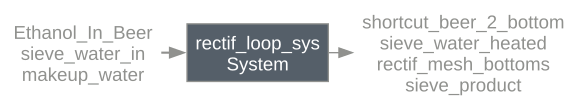

System: rectif_loop_sys
Highest convergence error among components in recycle
stream cooler_reflux-0 after 1 loops:
- flow rate   1.42e-14 kmol/hr (1.4e-12%)
- temperature 0.00e+00 K (0%)
ins...
[0] Ethanol_In_Beer  
    phase: 'l', T: 388.15 K, P: 607950 Pa
    flow (kmol/hr): Water       2.17e+04
                    Ethanol     467
                    AceticAcid  61
                    LacticAcid  23.7
                    Xylose      2.1
                    Extract     67.8
                    Ash         4.11e+03
                    ...         308
[1] sieve_water_in  
    phase: 'l', T: 306.15 K, P: 101325 Pa
    flow (kmol/hr): Water  6.92e+03
[2] makeup_water  
    phase: 'l', T: 298.15 K, P: 303975 Pa
    flow: 0
outs...
[0] shortcut_beer_2_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    flow (kmol/hr): Water       1.97e+04
                    Ethanol     4.06
                    AceticAcid  48.9
                    LacticAcid  23.7
                    Xylose      2.1
   

In [26]:
rectif_loop_sys

In [27]:
rectif_mesh.show(flow='kg/hr', composition=True)

MESHDistillation: rectif_mesh
ins...
[0] shortcut_beer_2_top  from  ShortcutColumn-D3
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] reflux_recycle  from  HXutility-cooler_reflux
    phases: ('g', 'l'), T: 344.15 K, P: 303975 Pa
    composition (%): (l) Water    27.7
                         Ethanol  72.3
                         -------  7.37e+03 kg/hr
outs...
[0] rectif_mesh_vapor  to  HXprocess-HX_sieve
    phase: 'g', T: 384.25 K, P: 303975 Pa
    composition (%): Water       19
                     Ethanol     80.9
                     AceticAcid  0.091
                     LacticAcid  3.72e-13
                     ----------  3.26e+04 kg/hr
[1] rectif_mesh_bottoms  
    phase: 'l', T: 406.01 K, P: 303975 Pa
    composition (%): Water       97.2
                     Ethanol     0.70

In [28]:
HX_sieve.results()

Heat exchanger                                            Units  HX_sieve
Design              Area                                   ft^2  1.66e+04
                    Overall heat transfer coefficient  kW/m^2/K         1
                    Log-mean temperature difference           K      7.66
                    Fouling correction factor                           1
                    Operating pressure                      psi      44.1
                    Total tube length                        ft        20
Purchase cost       Floating head                           USD  2.56e+05
Total purchase cost                                         USD  2.56e+05
Utility cost                                             USD/hr         0

In [29]:
rectif_mesh.outs[0].imass['Ethanol']/rectif_mesh.outs[0].F_mass

0.8091570206982828

In [30]:
rectif_mesh.results()

Distillation                                               Units  rectif_mesh
Electricity         Power                                     kW         2.75
                    Cost                                  USD/hr        0.227
Cooling water       Duty                                   kJ/hr    -1.85e+08
                    Flow                                 kmol/hr     1.26e+05
                    Cost                                  USD/hr         61.6
Low pressure steam  Duty                                   kJ/hr     3.24e+07
                    Flow                                 kmol/hr          837
                    Cost                                  USD/hr          199
Design              Theoretical stages                                     23
                    Actual stages                                          35
                    Height                                    ft         65.7
                    Diameter                                  ft         13.6
                    Wall thickness                            in        0.625
                    Weight                                    lb     8.39e+04
Purchase cost       Trays                                    USD     1.77e+05
                    Tower                                    USD     3.68e+05
                    Platform and ladders                     USD     7.55e+04
                    Condenser - Floating head                USD     2.44e+05
                    Reflux drum - Horizontal pressur...      USD     2.84e+04
                    Reflux drum - Platform and ladders       USD     4.85e+03
                    Pump - Pump                              USD     6.83e+03
                    Pump - Motor                             USD          664
                    Reboiler - Floating head                 USD     2.13e+05
Total purchase cost                                          USD     1.12e+06
Utility cost                                              USD/hr          261

In [31]:
rectif_mesh.show(flow='kg/hr',composition=True)

MESHDistillation: rectif_mesh
ins...
[0] shortcut_beer_2_top  from  ShortcutColumn-D3
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] reflux_recycle  from  HXutility-cooler_reflux
    phases: ('g', 'l'), T: 344.15 K, P: 303975 Pa
    composition (%): (l) Water    27.7
                         Ethanol  72.3
                         -------  7.37e+03 kg/hr
outs...
[0] rectif_mesh_vapor  to  HXprocess-HX_sieve
    phase: 'g', T: 384.25 K, P: 303975 Pa
    composition (%): Water       19
                     Ethanol     80.9
                     AceticAcid  0.091
                     LacticAcid  3.72e-13
                     ----------  3.26e+04 kg/hr
[1] rectif_mesh_bottoms  
    phase: 'l', T: 406.01 K, P: 303975 Pa
    composition (%): Water       97.2
                     Ethanol     0.70

In [32]:
rectification_shortcut.results()

Distillation Column                                        Units        D2
Electricity         Power                                     kW      3.05
                    Cost                                  USD/hr     0.252
Cooling water       Duty                                   kJ/hr -1.12e+08
                    Flow                                 kmol/hr  7.66e+04
                    Cost                                  USD/hr      37.4
Low pressure steam  Duty                                   kJ/hr  4.29e+07
                    Flow                                 kmol/hr  1.11e+03
                    Cost                                  USD/hr       264
Design              Theoretical feed stage                               2
                    Theoretical stages                                  23
                    Minimum reflux                         Ratio      5.11
                    Reflux                                 Ratio      5.36
                    Actual stages                                       35
                    Height                                    ft      62.7
                    Diameter                                  ft        13
                    Wall thickness                            in     0.625
                    Weight                                    lb  7.68e+04
Purchase cost       Trays                                    USD  1.62e+05
                    Tower                                    USD  3.46e+05
                    Platform and ladders                     USD  7.08e+04
                    Condenser - Floating head                USD  1.68e+05
                    Reflux drum - Horizontal pressur...      USD  3.19e+04
                    Reflux drum - Platform and ladders       USD  4.93e+03
                    Pump - Pump                              USD  6.95e+03
                    Pump - Motor                             USD       678
                    Reboiler - Floating head                 USD  3.56e+05
Total purchase cost                                          USD  1.15e+06
Utility cost                                              USD/hr       301

In [33]:
rectification_shortcut.show(flow='kg/hr',composition=True)

ShortcutColumn: D2
ins...
[0] shortcut_beer_top  from  ShortcutColumn-D1
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
outs...
[0] shortcut_rectif_top  
    phase: 'g', T: 382.22 K, P: 303975 Pa
    composition (%): Water       7.25
                     Ethanol     92.7
                     AceticAcid  0.00184
                     ----------  2.3e+04 kg/hr
[1] shortcut_rectif_bottom  
    phase: 'l', T: 406.96 K, P: 303975 Pa
    composition (%): Water       97.9
                     Ethanol     0.0491
                     AceticAcid  2.06
                     LacticAcid  0.000122
                     ----------  3.54e+04 kg/hr
